# RAM Delay Intelligence — Exploration des données (EDA)

**Projet :** Analyse et prédiction de la ponctualité des flottes Royal Air Maroc
**Source :** extraction consolidée NETLINE (vols temps réel) / AMOS (maintenance technique)
**Période :** 29 mars 2025 → 24 juin 2025
**Granularité :** 1 ligne = 1 segment de vol (leg)

Ce notebook explore le dataset brut, justifie les choix de nettoyage et de
feature engineering effectués dans `src/data_processing.py`, et prépare le
terrain pour la modélisation (`src/model.py`).

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

from data_processing import load_raw, clean_and_engineer

## 1. Chargement et aperçu du dataset brut

In [2]:
df_raw = load_raw('../data/RAM_raw.xlsx')
print(f"Shape: {df_raw.shape}")
df_raw.head(3)

Shape: (17017, 70)


,FN_CARRIER,FN_NUMBER,DAY_OF_ORIGIN,AC_OWNER,AC_SUBTYPE,MC_LC_CC,AC_VERSION,AC_REGISTRATION,DEP_AP_SCHED,ARR_AP_SCHED,DEP_AP_ACTUAL,ARR_AP_ACTUAL,O/D,SECTEUR_ORIGIN,SECTEUR_DESTINATION,LEG_STATE,LEG_TYPE,DEP_DAY_SCHED,DAY_OF_WEEK_DEP,Month DEP DAY SCHED,DEP_TIME_SCHED,ARR_DAY_SCHED,ARR_TIME_SCHED,OFFBLOCK_DAY,OFFBLOCK_TIME,...,DELAY_TIME_01,DELAY_CODE_02,DELAY_TIME_02,DELAY_CODE_03,DELAY_TIME_03,CODE_DR,FAMILLE_DR,LIB_CODE_DR,Retard en min,Tranch Retard départ,Tranch Retard départ 30,Type retard départ,TRAFIC,RCR Code,RCR numero vol,RCR Date,ESC Départ RCR,ESC Arrivé RCR,RCR LIB CODE DR,RCR Famille DR,LIB_CODE_DR_FUSION,FAMILLE_DR_FUSION,Interne/Externe,AT_RXP_AFFRT,GROUP_AVION
0,AT,593,2025-03-29,AT,73H,MC,JY159,CNRGK,OXB,RAI,OXB,RAI,OXB/RAI,AFR,AFR,ARR,J,2025-03-30,dimanche,mars,02:25,2025-03-30,04:10,2025-03-30,03:13,...,48,0,00:00:00,0,00:00,93,ROTATION,ROT,48,16min<=R<1h,30min<=R<1h,R,99,91,0593,2025-03-29 22:07:00,CMN,OXB,COR,CORRESPONDANCE,COR,CORRESPONDANCE,Interne,AT,NG
1,AT,593,2025-03-29,AT,73H,MC,JY159,CNRGK,RAI,CMN,RAI,CMN,RAI/CMN,AFR,CMN,ARR,J,2025-03-30,dimanche,mars,05:10,2025-03-30,08:40,2025-03-30,05:36,...,26,0,00:00:00,0,00:00,93,ROTATION,ROT,26,16min<=R<1h,16min<=R<30min,R,0,91,0593,2025-03-29 22:07:00,CMN,OXB,COR,CORRESPONDANCE,COR,CORRESPONDANCE,Interne,AT,NG
2,AT,220,2025-03-29,AT,73H,MC,JY159,CNROL,TUN,SVO,TUN,SVO,TUN/SVO,AFR,EUR,ARR,J,2025-03-30,dimanche,mars,01:10,2025-03-30,06:10,2025-03-30,01:47,...,37,0,00:00:00,0,00:00,93,ROTATION,ROT,37,16min<=R<1h,30min<=R<1h,R,147,81,0220,2025-03-29 22:14:00,CMN,TUN,ATC,ATC,ATC,ATC,Interne,AT,NG


In [3]:
print(f"Période couverte : {df_raw['DAY_OF_ORIGIN'].min()} -> {df_raw['DAY_OF_ORIGIN'].max()}")
print(f"Nombre de colonnes : {df_raw.shape[1]}")
print(f"Valeurs manquantes (NaN réels) : {df_raw.isna().sum().sum()}")

Période couverte : 2025-03-29 00:00:00 -> 2025-06-24 00:00:00
Nombre de colonnes : 70
Valeurs manquantes (NaN réels) : 0


**Observation clé :** le dataset ne contient aucune valeur `NaN` au sens
pandas. Les "manques" métier (motif de retard non renseigné, etc.) sont
encodés par des placeholders (`'-'`, `0`) plutôt que par de vrais NaN. Il
faut donc les gérer explicitement plutôt que de se fier à `isna()`.

## 2. La cible : durée de retard à l'arrivée

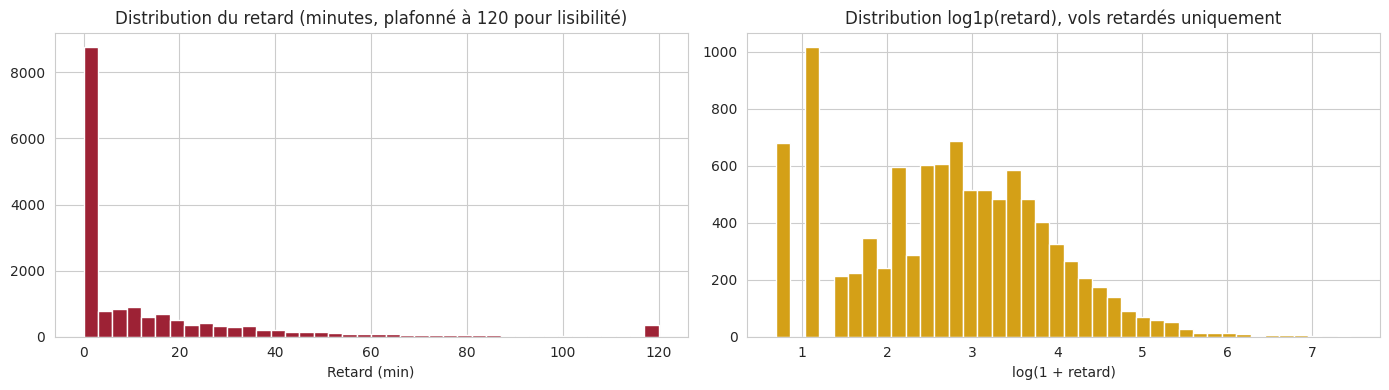

Skewness (asymétrie) du retard brut : 13.65
Skewness après log1p (vols retardés) : 0.11


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_raw['Retard en min'].clip(upper=120), bins=40, color='#9D2235')
axes[0].set_title("Distribution du retard (minutes, plafonné à 120 pour lisibilité)")
axes[0].set_xlabel('Retard (min)')

delayed = df_raw[df_raw['Retard en min'] > 0]['Retard en min']
axes[1].hist(np.log1p(delayed), bins=40, color='#D4A017')
axes[1].set_title("Distribution log1p(retard), vols retardés uniquement")
axes[1].set_xlabel('log(1 + retard)')
plt.tight_layout()
plt.show()

print(f"Skewness (asymétrie) du retard brut : {df_raw['Retard en min'].skew():.2f}")
print(f"Skewness après log1p (vols retardés) : {np.log1p(delayed).skew():.2f}")

**Décision méthodologique :** la distribution brute du retard est extrêmement
asymétrique (skew ≈ 11), avec une longue traîne jusqu'à 1732 minutes. Pour
le modèle de régression (Modèle 2), on entraînera donc sur `log1p(retard)`
plutôt que sur la valeur brute, ce qui stabilise fortement la variance
(skew ramené à un niveau largement plus exploitable par un modèle linéaire
ou à base d'arbres).

## 3. Les motifs de retard : 3 colonnes candidates

In [5]:
for col in ['FAMILLE_DR', 'FAMILLE_DR_FUSION', 'RCR Famille DR']:
    print(f"--- {col} ---")
    print(df_raw[col].value_counts().head(6))
    print()

--- FAMILLE_DR ---
FAMILLE_DR
-                 8761
ROTATION          3473
ATC               2003
CORRESPONDANCE     863
TECHNIQIE          365
TIERS 2            310
Name: count, dtype: int64

--- FAMILLE_DR_FUSION ---
FAMILLE_DR_FUSION
-                 8761
ATC               2763
CORRESPONDANCE    1266
ROTATION          1237
TECHNIQIE          648
AVARIE             527
Name: count, dtype: int64

--- RCR Famille DR ---
RCR Famille DR
-                 13544
ROTATION           1237
ATC                 760
CORRESPONDANCE      403
TECHNIQIE           283
AVARIE              221
Name: count, dtype: int64



In [6]:
# Vérification de cohérence : un retard non nul doit toujours avoir un motif renseigné
# dans la colonne choisie comme cible
for col in ['FAMILLE_DR', 'FAMILLE_DR_FUSION']:
    incoherent = ((df_raw['Retard en min'] > 0) & (df_raw[col] == '-')).sum()
    print(f"{col}: {incoherent} vols retardés sans motif renseigné")

FAMILLE_DR: 1698 vols retardés sans motif renseigné
FAMILLE_DR_FUSION: 1698 vols retardés sans motif renseigné


**Choix :** `FAMILLE_DR_FUSION` est retenue comme cible pour le Modèle 3.
Elle présente la même cohérence que `FAMILLE_DR` vis-à-vis du retard
(aucune incohérence), mais reflète probablement la version consolidée /
finale du motif (vs. `RCR Famille DR` qui semble être une version
retraitée a posteriori avec beaucoup plus de "-" — donc moins complète).

Les ~1700 vols en retard sans motif renseigné (`'-'`) sont un signal en
soi : ils illustrent concrètement le problème de *"mauvaise mise à jour
des motifs de retard"* identifié dans le rapport de stage original. On les
exclura de l'entraînement du Modèle 3 (ce ne sont pas des labels valides),
mais le taux de non-renseignement est lui-même reporté comme KPI dans le
dashboard (module Analytics).

## 4. Construction du dataset propre

In [7]:
df = clean_and_engineer(df_raw)
print(f"Shape après feature engineering : {df.shape}")
df[['retard_min', 'is_delayed', 'famille_retard', 'jour_semaine', 'periode_journee']].sample(5, random_state=0)

Shape après feature engineering : (17017, 92)


,retard_min,is_delayed,famille_retard,jour_semaine,periode_journee
16812,115.0,1,AUTRES,lundi,Après-midi (12h-18h)
9610,0.0,0,AUCUN,dimanche,Après-midi (12h-18h)
15589,0.0,0,AUCUN,mercredi,Soir (18h-24h)
11124,0.0,0,AUCUN,dimanche,Nuit (00h-06h)
1847,27.0,1,AVARIE,mardi,Matin (06h-12h)


## 5. Exploration des facteurs de retard

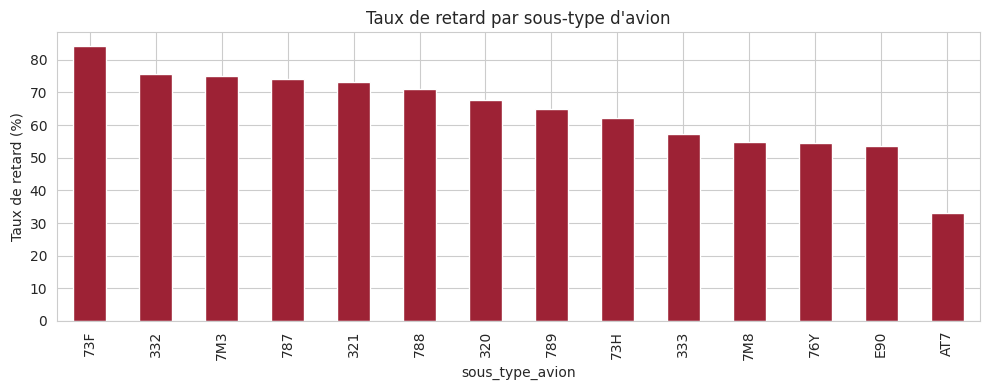

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
rate_by_subtype = df.groupby('sous_type_avion')['is_delayed'].mean().sort_values(ascending=False) * 100
rate_by_subtype.plot(kind='bar', color='#9D2235', ax=ax)
ax.set_ylabel('Taux de retard (%)')
ax.set_title("Taux de retard par sous-type d'avion")
plt.tight_layout()
plt.show()

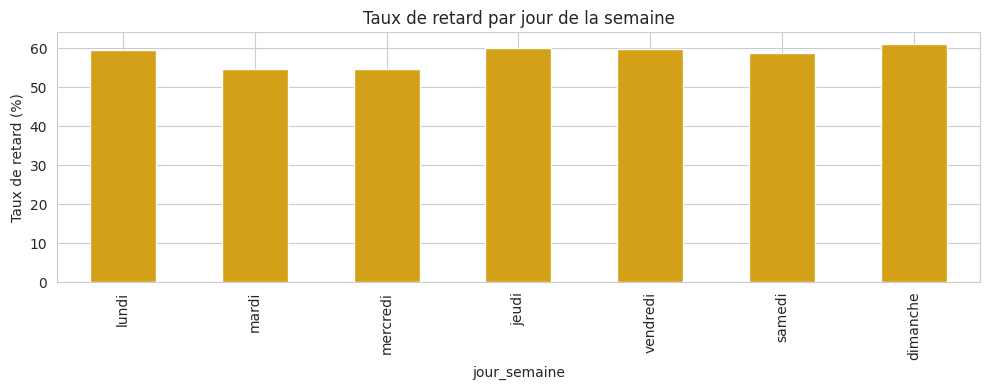

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
order = ['lundi','mardi','mercredi','jeudi','vendredi','samedi','dimanche']
rate_by_day = df.groupby('jour_semaine', observed=True)['is_delayed'].mean().reindex(order) * 100
rate_by_day.plot(kind='bar', color='#D4A017', ax=ax)
ax.set_ylabel('Taux de retard (%)')
ax.set_title('Taux de retard par jour de la semaine')
plt.tight_layout()
plt.show()

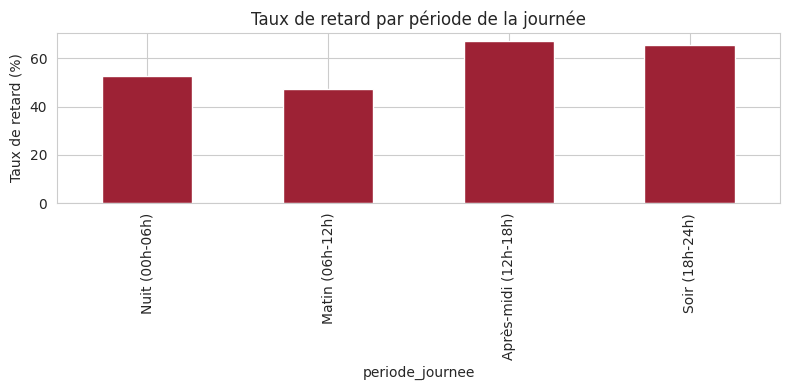

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
order_period = ['Nuit (00h-06h)', 'Matin (06h-12h)', 'Après-midi (12h-18h)', 'Soir (18h-24h)']
rate_by_period = df.groupby('periode_journee')['is_delayed'].mean().reindex(order_period) * 100
rate_by_period.plot(kind='bar', color='#9D2235', ax=ax)
ax.set_ylabel('Taux de retard (%)')
ax.set_title('Taux de retard par période de la journée')
plt.tight_layout()
plt.show()

**Observations :**
- Les avions cargo/anciens (73F, 332) affichent les taux de retard les plus
  élevés — pistes d'investigation opérationnelle concrètes.
- Le taux de retard reste élevé sur toute la semaine (54-61%), avec un pic
  le dimanche — cohérent avec la reprise du trafic après le creux du
  samedi et les correspondances internationales.
- Les vols de nuit et du soir sont plus à risque, probablement par effet
  de propagation des retards accumulés dans la journée (rotation d'avion).

## 6. Sauvegarde du dataset nettoyé

In [11]:
from data_processing import build_clean_dataset

df_clean = build_clean_dataset(raw_path='../data/RAM_raw.xlsx', out_path='../data/RAM_clean.parquet')
print(f"Dataset nettoyé sauvegardé : {df_clean.shape}")

Dataset nettoyé sauvegardé : (17017, 92)
